# No preamble

2026-04-06 12:26:05 [INFO] [commstools/sync.py] Applying Löwdin IQ imbalance compensation.
OFFSET: -652577718.0989583


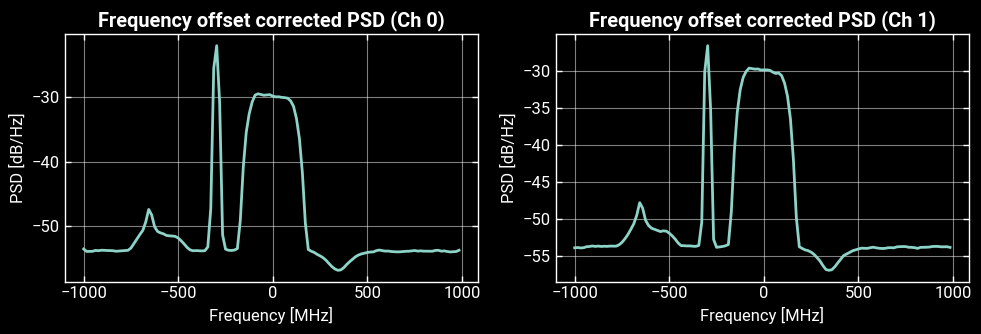

In [33]:
# Fix IQ imbalance and take a slice for processing

from commstools import Signal, load_npz
from commstools.backend import dispatch
from commstools.equalization import lms, rde, block_lms
from commstools.sync import (
    compensate_iq_imbalance_lowdin,
    correct_carrier_phase,
    correct_frequency_offset,
    correct_timing,
    estimate_timing,
    recover_carrier_phase_bps,
    recover_carrier_phase_pll,
    estimate_frequency_offset_blockwise,
)

signal = load_npz("/home/lokgar/repos/trmhi304-p2p/waveforms/signal_16qam")

_, xp, _ = dispatch(signal.samples)

# signal.plot_waveform(show=True, num_symbols=71 * 2, title="Frame")
# signal.plot_psd(show=True)
digoff = signal.digital_frequency_offset
signal.shift_frequency(-digoff)
signal.resample(up=1, down=2)
# signal.plot_psd(show=True)

_samples = xp.load(
    "/home/lokgar/repos/trmhi304-p2p/captures/capture_16qam_intradyne_long.npy"
)
samples = xp.array([_samples[0] + 1j * _samples[1], _samples[2] + 1j * _samples[3]])

segment_len = signal.samples.shape[-1]
num_tiles = samples.shape[-1] // segment_len
cut_length = num_tiles * segment_len

samples = samples[:, :cut_length]

samples = compensate_iq_imbalance_lowdin(xp.conj(samples))

num_mult = 3

sig = Signal(
    samples=samples[:, : segment_len * num_mult],
    sampling_rate=signal.sampling_rate,
    symbol_rate=signal.symbol_rate,
    mod_scheme=signal.frame.payload_mod_scheme,
    mod_order=signal.frame.payload_mod_order,
    frame=signal.frame,
    source_bits=xp.tile(signal.frame.payload_bits, (1, num_mult)),
    source_symbols=xp.tile(signal.frame.payload_symbols, (1, num_mult)),
    pulse_shape=signal.pulse_shape,
)

f, Pxx = sig.welch_psd(nperseg=sig.samples.shape[-1])
ofst = -f[Pxx[0].argmax()] - digoff
print(f"OFFSET: {ofst}")
sig.samples = correct_frequency_offset(sig.samples, sig.sampling_rate, -ofst)

sig.plot_psd(show=True, title="Frequency offset corrected PSD")


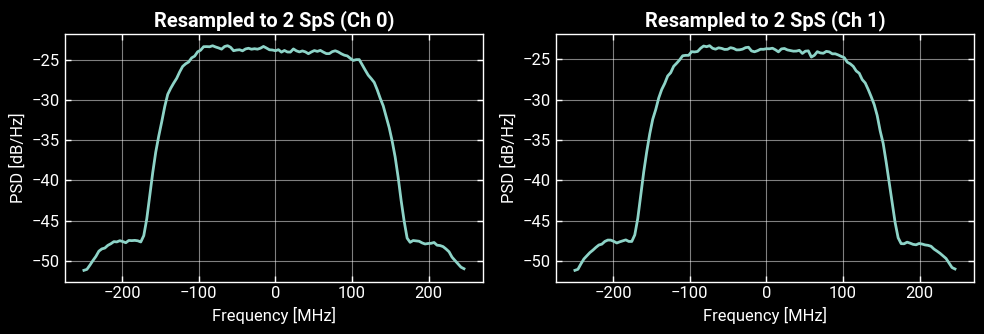

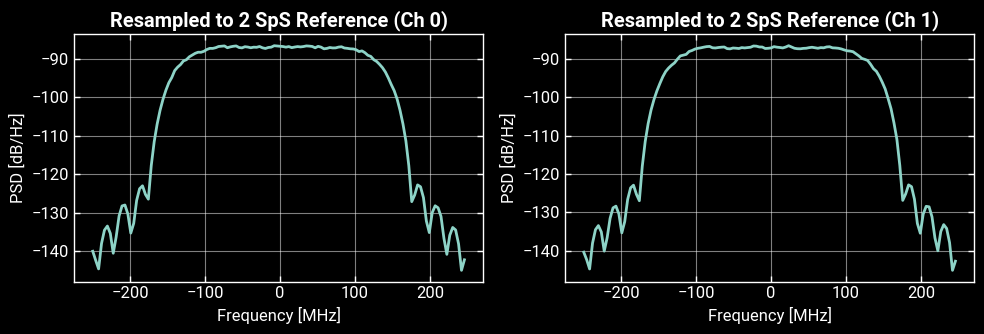

2026-04-06 12:26:07 [WARNING] [commstools/sync.py] Channel 0: Peak phase coherence is very low (0.36), but peak is visually prominent (PAPR=45.3 >= 6). This suggests strong Carrier Frequency Offset (CFO) or uncompensated dispersion destroying phase alignment over the sequence length.
2026-04-06 12:26:07 [WARNING] [commstools/sync.py] Channel 1: Peak phase coherence is very low (0.37), but peak is visually prominent (PAPR=45.9 >= 6). This suggests strong Carrier Frequency Offset (CFO) or uncompensated dispersion destroying phase alignment over the sequence length.
2026-04-06 12:26:07 [WARNING] [commstools/sync.py] Skew detected among valid channels! Valid Peaks: [80326, 80325]. Spread: 1 samples.


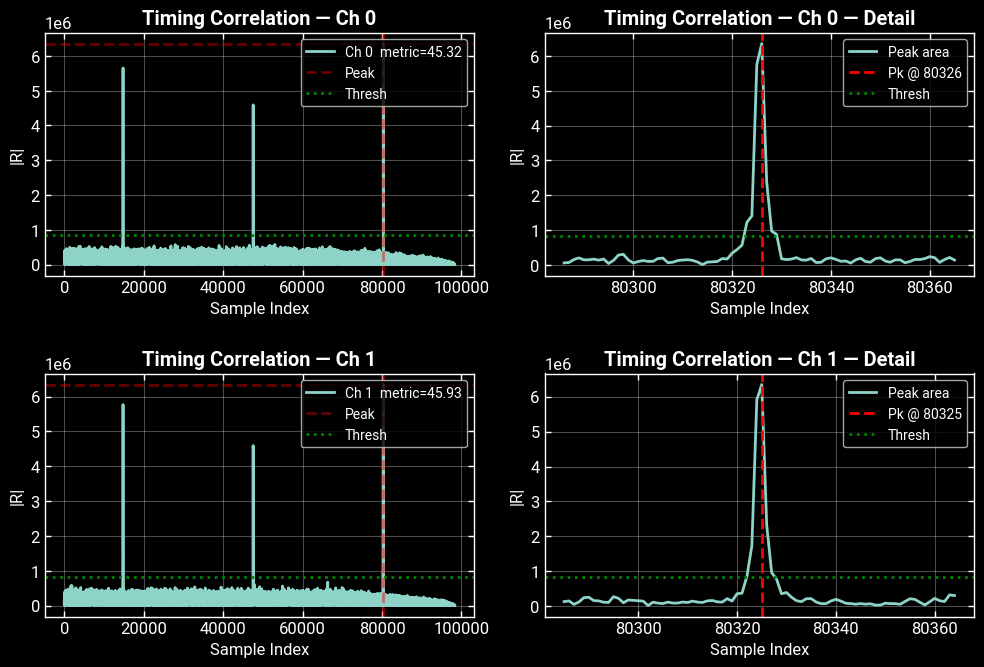

2026-04-06 12:26:07 [INFO] [commstools/sync.py] Timing estimated. Coarse: [80326, 80325], Fractional: [-0.4076178864092483, -0.43382885428584245], Metrics: [45.32218337574124, 45.93215441855087]
2026-04-06 12:26:07 [INFO] [commstools/sync.py] Timing corrected: coarse=[80326, 80325], fractional=applied, mode='circular'.
2026-04-06 12:26:07 [INFO] [commstools/core.py] Generating shaping filter taps (shape: rrc).


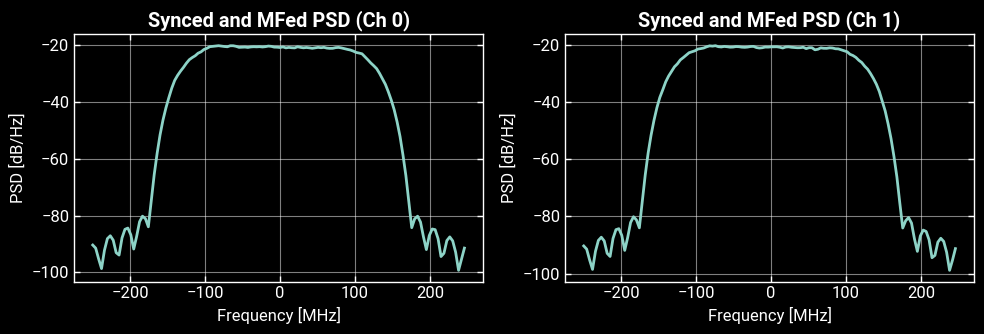

In [34]:
sig.resample(sps_out=2)
signal.resample(sps_out=2)

sig.plot_psd(show=True, title="Resampled to 2 SpS")
signal.plot_psd(show=True, title="Resampled to 2 SpS Reference")

coarse, fract = estimate_timing(
    sig.samples,
    signal.samples,
    # pulse_shape=sig.pulse_shape,
    sps=sig.sps,
    debug_plot=True,
    threshold=6,
)
sig.samples = correct_timing(sig.samples, coarse, fract, mode="circular")

sig.matched_filter()
sig.plot_psd(show=True, title="Synced and MFed PSD")


2026-04-06 13:24:18 [INFO] [commstools/equalization.py] Block-LMS: C=2, num_taps=75, sps=2, block_size=256, fftsize=1024, mu=0.1, n_sym=8192, cpr=bps(P=1024, K=32, joint, cs_corr=True(thr=0.785))
2026-04-06 13:24:18 [INFO] [commstools/equalization.py] Block-LMS: exit MSE (final 100 symbols): ch0=1.0, ch1=0.6 dB
2026-04-06 13:24:18 [INFO] [commstools/equalization.py] Block-LMS: C=2, num_taps=75, sps=2, block_size=256, fftsize=1024, mu=0.1, n_sym=8192, cpr=bps(P=1024, K=32, joint, cs_corr=True(thr=0.785))
2026-04-06 13:24:18 [INFO] [commstools/equalization.py] Block-LMS: exit MSE (final 100 symbols): ch0=-2.7, ch1=-2.9 dB
2026-04-06 13:24:18 [INFO] [commstools/equalization.py] Block-LMS: C=2, num_taps=75, sps=2, block_size=256, fftsize=1024, mu=0.1, n_sym=8192, cpr=bps(P=1024, K=32, joint, cs_corr=True(thr=0.785))
2026-04-06 13:24:18 [INFO] [commstools/equalization.py] Block-LMS: exit MSE (final 100 symbols): ch0=-3.8, ch1=-4.4 dB
2026-04-06 13:24:18 [INFO] [commstools/equalization.py] B

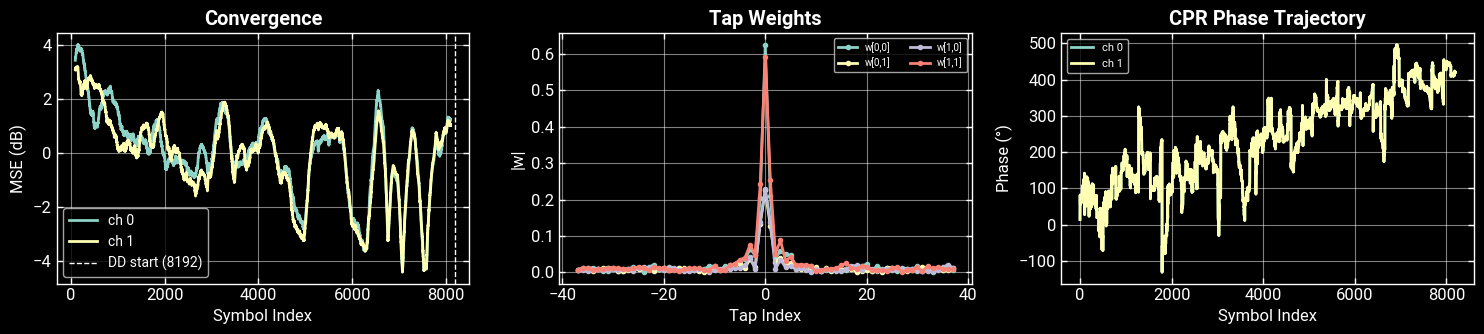

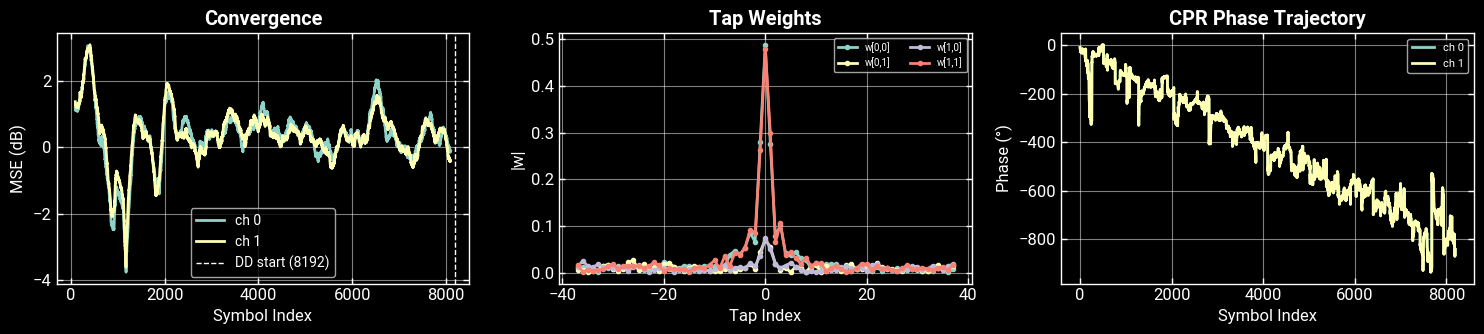

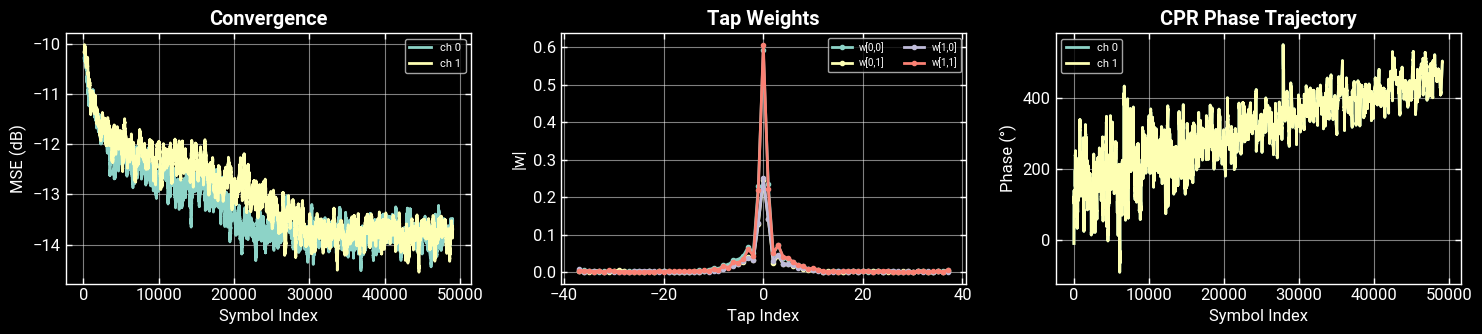

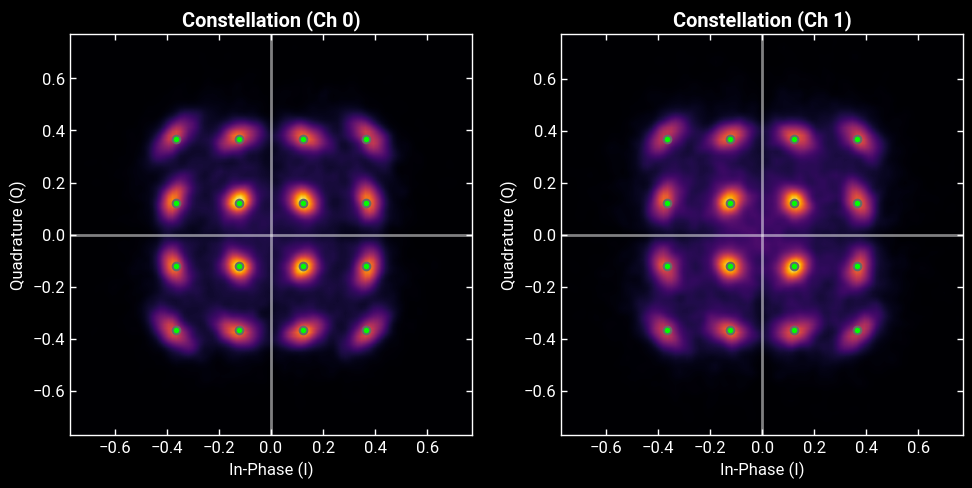

2026-04-06 13:24:22 [INFO] [commstools/sync.py] CPR (BPS, B=1024, joint): phase mean=-0.74°, std=10.52° [1536 blocks x 32 symbols, C=2, cycle_slip_correction=True]


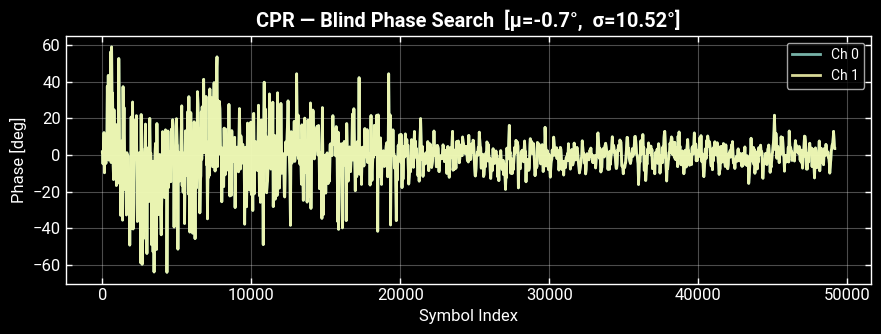

2026-04-06 13:24:22 [WARNING] [commstools/sync.py] loop_filter='butterworth': mu and beta are ignored. Use loop_bandwidth_normalized to control loop bandwidth.
2026-04-06 13:24:22 [INFO] [commstools/sync.py] CPR (DD-PLL, Butterworth, BW=0.2): phase mean=-34.64°, std=560.63° [C=2]


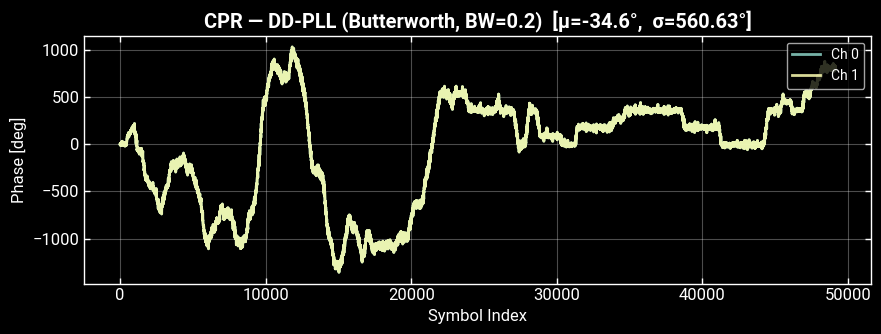

2026-04-06 13:24:22 [INFO] [commstools/core.py] Signal already at 1 sps, no downsampling needed.
2026-04-06 13:24:22 [INFO] [commstools/metrics.py] SER: 9.04e-01 (44429/49152 errors)
2026-04-06 13:24:22 [INFO] [commstools/metrics.py] SER: 7.91e-01 (38858/49152 errors)
2026-04-06 13:24:22 [INFO] [commstools/metrics.py] SER: 6.95e-01 (34168/49152 errors)
2026-04-06 13:24:22 [INFO] [commstools/metrics.py] SER: 8.23e-01 (40435/49152 errors)
2026-04-06 13:24:22 [INFO] [commstools/sync.py] Phase ambiguity resolution: ch=0, best_k=2, rotation=180.0°, SER=0.6951
2026-04-06 13:24:22 [INFO] [commstools/metrics.py] SER: 9.11e-01 (44780/49152 errors)
2026-04-06 13:24:22 [INFO] [commstools/metrics.py] SER: 8.14e-01 (40022/49152 errors)
2026-04-06 13:24:22 [INFO] [commstools/metrics.py] SER: 7.21e-01 (35421/49152 errors)
2026-04-06 13:24:22 [INFO] [commstools/metrics.py] SER: 8.37e-01 (41116/49152 errors)
2026-04-06 13:24:22 [INFO] [commstools/sync.py] Phase ambiguity resolution: ch=1, best_k=2, rot

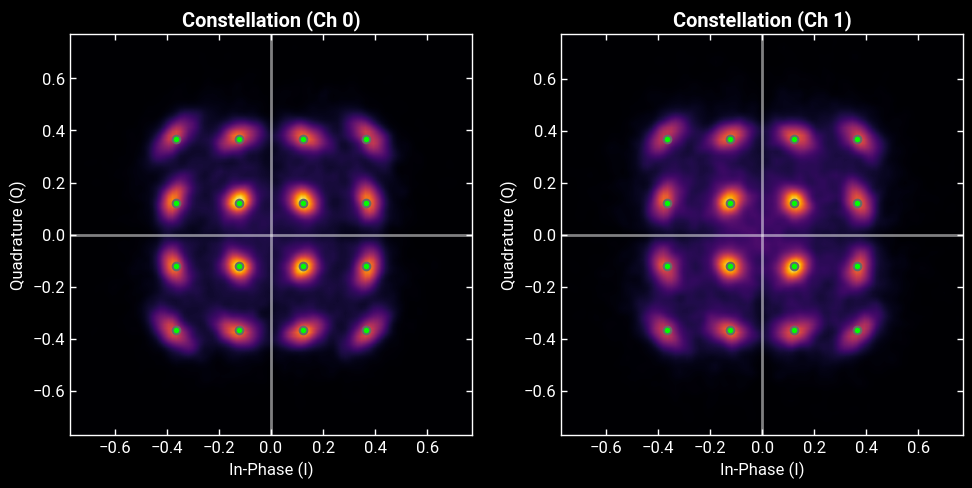

2026-04-06 13:24:23 [INFO] [commstools/core.py] Discarding 8192 training symbols for EVM calculation.
2026-04-06 13:24:23 [INFO] [commstools/metrics.py] EVM [blind] Ch0: 19.55% (-14.18 dB)
2026-04-06 13:24:23 [INFO] [commstools/metrics.py] EVM [blind] Ch1: 22.52% (-12.95 dB)
2026-04-06 13:24:23 [INFO] [commstools/core.py] Discarding 8192 training symbols for SER calculation.
2026-04-06 13:24:23 [INFO] [commstools/metrics.py] SER Ch0: 6.57e-01 (26907/40960 errors)
2026-04-06 13:24:23 [INFO] [commstools/metrics.py] SER Ch1: 6.84e-01 (28018/40960 errors)
2026-04-06 13:24:23 [INFO] [commstools/core.py] Discarding 8192 training symbols for SNR calculation.
2026-04-06 13:24:23 [INFO] [commstools/metrics.py] SNR Ch0: -1.57 dB
2026-04-06 13:24:23 [INFO] [commstools/metrics.py] SNR Ch1: -1.63 dB


array([-1.5686634, -1.6264474], dtype=float32)

In [65]:
numeq = 5
num_train_symbols = 2**13
num_taps = 75

block_size = 256
step_size = 1e-1

cpr_type = "bps"

cpr_cycle_slip_correction = True
cpr_cycle_slip_history = 128
cpr_cycle_slip_threshold = xp.pi / 4

cpr_bps_test_phases = 1024
cpr_bps_block_size = 32

cpr_pll_bandwidth = 0.2


for i in range(numeq):
    if i == 0:
        res = block_lms(
            samples=sig.samples[:, : num_train_symbols * 2],
            training_symbols=sig.source_symbols[:, :num_train_symbols],
            modulation=sig.mod_scheme,
            order=sig.mod_order,
            num_taps=num_taps,
            step_size=step_size,
            sps=sig.sps,
            plot_smoothing=200,
            debug_plot=True,
            block_size=block_size,
            cpr_type=cpr_type,
            cpr_bps_joint_channels=True,
            cpr_bps_test_phases=cpr_bps_test_phases,
            cpr_bps_block_size=cpr_bps_block_size,
            cpr_cycle_slip_correction=cpr_cycle_slip_correction,
            cpr_cycle_slip_history=cpr_cycle_slip_history,
            cpr_cycle_slip_threshold=cpr_cycle_slip_threshold,
        )
    elif i == numeq - 1:
        res = block_lms(
            samples=sig.samples[:, : num_train_symbols * 2],
            training_symbols=sig.source_symbols[:, :num_train_symbols],
            modulation=sig.mod_scheme,
            order=sig.mod_order,
            num_taps=num_taps,
            step_size=step_size,
            sps=sig.sps,
            plot_smoothing=200,
            debug_plot=True,
            block_size=block_size,
            cpr_type=cpr_type,
            cpr_bps_joint_channels=True,
            cpr_bps_test_phases=cpr_bps_test_phases,
            cpr_bps_block_size=cpr_bps_block_size,
            cpr_cycle_slip_correction=cpr_cycle_slip_correction,
            cpr_cycle_slip_history=cpr_cycle_slip_history,
            cpr_cycle_slip_threshold=cpr_cycle_slip_threshold,
            w_init=res.weights,
        )
    else:
        res = block_lms(
            samples=sig.samples[:, : num_train_symbols * 2],
            training_symbols=sig.source_symbols[:, :num_train_symbols],
            modulation=sig.mod_scheme,
            order=sig.mod_order,
            num_taps=num_taps,
            step_size=step_size,
            sps=sig.sps,
            plot_smoothing=200,
            debug_plot=False,
            block_size=block_size,
            cpr_type=cpr_type,
            cpr_bps_joint_channels=True,
            cpr_bps_test_phases=cpr_bps_test_phases,
            cpr_bps_block_size=cpr_bps_block_size,
            cpr_cycle_slip_correction=cpr_cycle_slip_correction,
            cpr_cycle_slip_history=cpr_cycle_slip_history,
            cpr_cycle_slip_threshold=cpr_cycle_slip_threshold,
            w_init=res.weights,
        )


res = block_lms(
    samples=sig.samples,
    modulation=sig.mod_scheme,
    order=sig.mod_order,
    num_taps=num_taps,
    step_size=step_size,
    sps=sig.sps,
    plot_smoothing=200,
    debug_plot=True,
    block_size=block_size,
    cpr_type=cpr_type,
    cpr_bps_joint_channels=True,
    cpr_bps_test_phases=cpr_bps_test_phases,
    cpr_bps_block_size=cpr_bps_block_size,
    cpr_cycle_slip_correction=cpr_cycle_slip_correction,
    cpr_cycle_slip_history=cpr_cycle_slip_history,
    cpr_cycle_slip_threshold=cpr_cycle_slip_threshold,
    w_init=res.weights,
)

eq = sig.copy()
eq.samples = res.y_hat
eq.sampling_rate = sig.symbol_rate

eq.plot_constellation(show=True, overlay_ideal=True)


# CPR
phases_bps = recover_carrier_phase_bps(
    eq.samples,
    modulation=eq.mod_scheme,
    order=eq.mod_order,
    debug_plot=True,
    block_size=cpr_bps_block_size,
    num_test_phases=cpr_bps_test_phases,
    cycle_slip_correction=cpr_cycle_slip_correction,
    cycle_slip_history=cpr_cycle_slip_history,
    cycle_slip_threshold=xp.pi / 4,
    joint_channels=True,
)
phases_pll = recover_carrier_phase_pll(
    eq.samples,
    modulation=eq.mod_scheme,
    order=eq.mod_order,
    debug_plot=True,
    loop_filter="butterworth",
    loop_bandwidth_normalized=cpr_pll_bandwidth,
    mu=0.2,
    beta=0.00025,
    cycle_slip_correction=cpr_cycle_slip_correction,
    cycle_slip_history=cpr_cycle_slip_history,
    joint_channels=True,
)

# Recover carrier phase

eqfoecpr = eq.copy()

# eqfoecpr.samples = correct_carrier_phase(eqfoecpr.samples, phases_bps)

eqfoecpr.resolve_symbols()
eqfoecpr.resolve_phase_ambiguity()
eqfoecpr.demap_symbols_hard()

eqfoecpr.plot_constellation(show=True, overlay_ideal=True)


eqfoecpr.evm(num_train_symbols=num_train_symbols, mode="blind")
eqfoecpr.ser(num_train_symbols=num_train_symbols)
eqfoecpr.snr(num_train_symbols=num_train_symbols)


2026-04-06 13:17:52 [INFO] [commstools/equalization.py] LMS equalizer: num_taps=75, mu=0.008, sps=2.0, backend=numba, n_train=8192, cpr=bps
2026-04-06 13:17:52 [WARNING] [commstools/equalization.py] LMS output y_hat is at 1 SPS (symbol rate). Update sampling_rate = symbol_rate after applying this equalizer.
2026-04-06 13:17:52 [INFO] [commstools/equalization.py] LMS: exit MSE (final 100 symbols): ch0=-21.7, ch1=-21.5 dB
2026-04-06 13:17:52 [INFO] [commstools/equalization.py] LMS equalizer: num_taps=75, mu=0.008, sps=2.0, backend=numba, n_train=8192, cpr=bps
2026-04-06 13:17:52 [WARNING] [commstools/equalization.py] LMS output y_hat is at 1 SPS (symbol rate). Update sampling_rate = symbol_rate after applying this equalizer.
2026-04-06 13:17:52 [INFO] [commstools/equalization.py] LMS: exit MSE (final 100 symbols): ch0=-21.9, ch1=-21.6 dB
2026-04-06 13:17:52 [INFO] [commstools/equalization.py] LMS equalizer: num_taps=75, mu=0.008, sps=2.0, backend=numba, n_train=8192, cpr=bps
2026-04-06 1

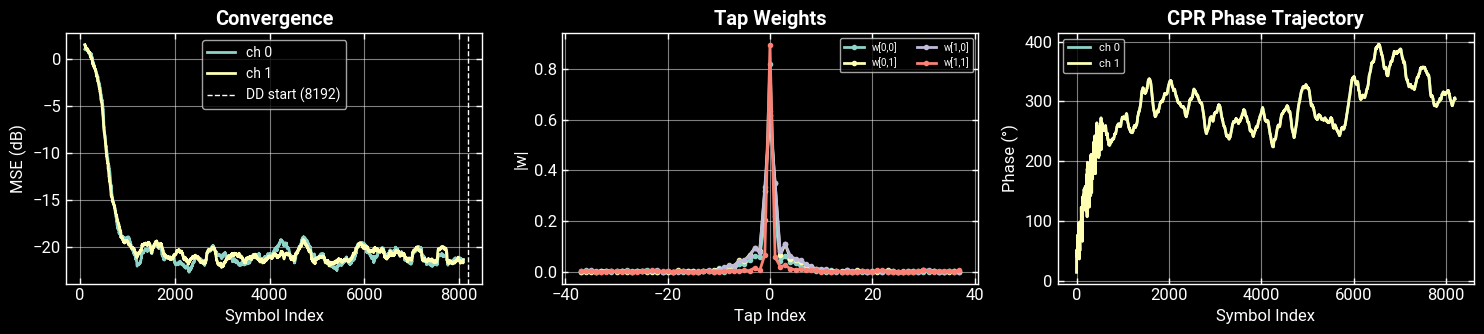

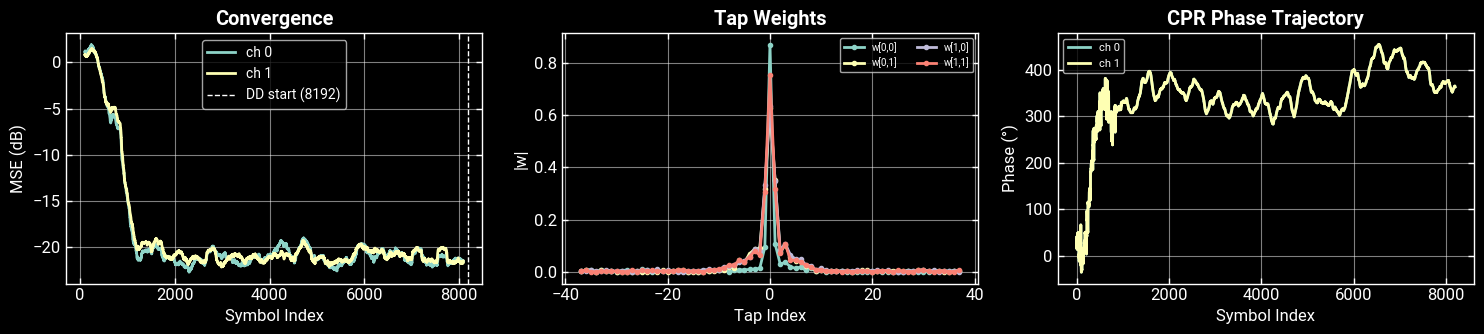

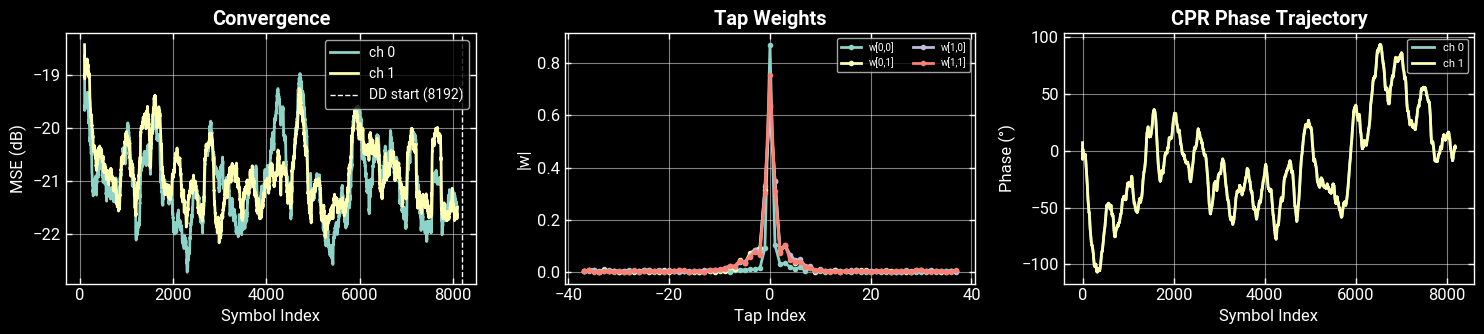

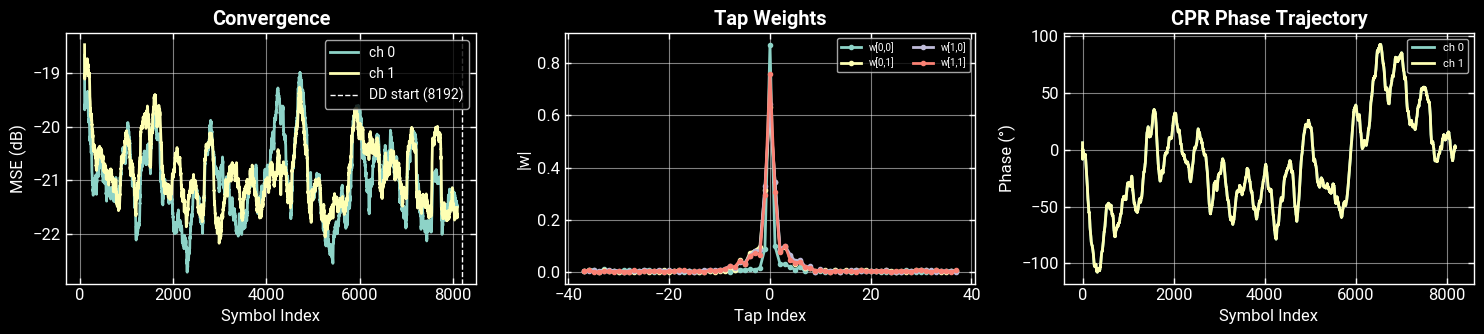

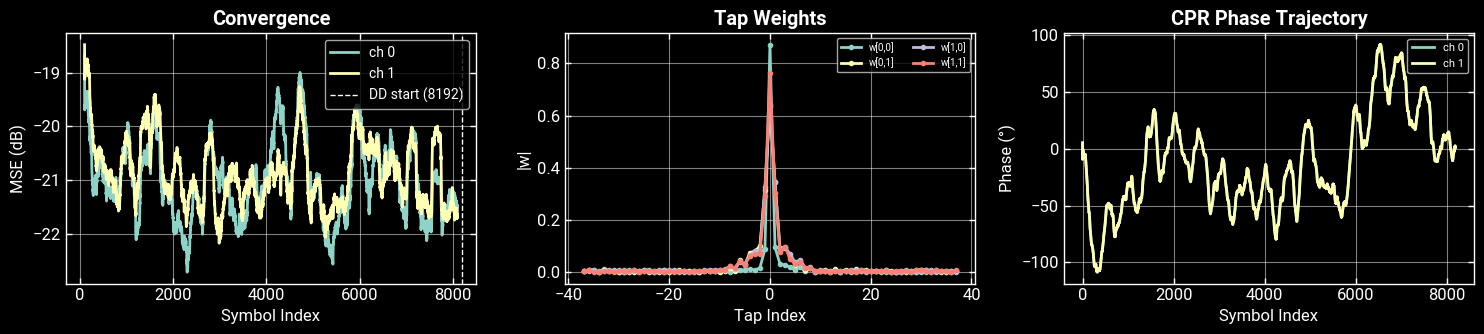

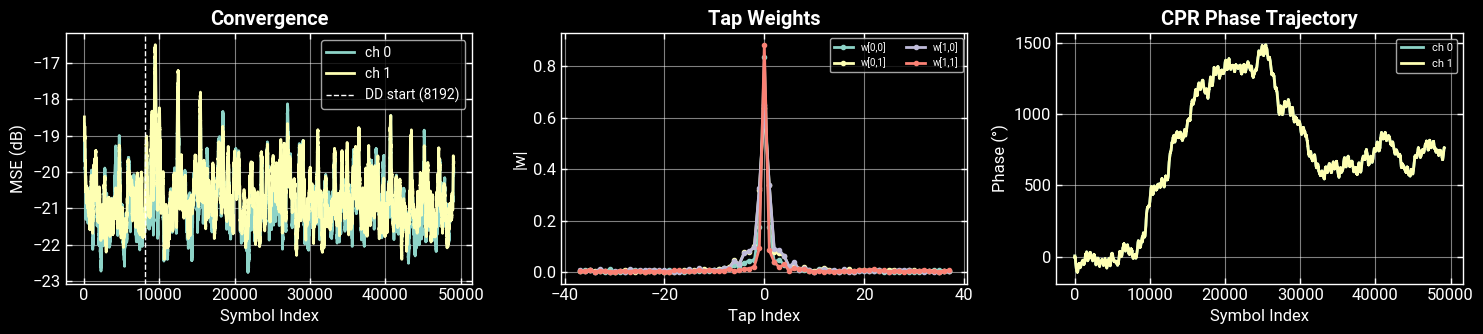

In [54]:
preeqsig = sig.copy()

numeq = 5
num_train_symbols = 2**13
num_taps = 75

step_size = 8e-3
cpr_type = "bps"
cpr_cycle_slip_correction = True
cpr_cycle_slip_history = 128
cpr_cycle_slip_threshold = xp.pi / 4
cpr_bps_test_phases = 1024
cpr_bps_block_size = 16
cpr_joint_channels = True

cpr_pll_bandwidth = 0.2

for i in range(numeq):
    if i == 0:
        res = lms(
            samples=preeqsig.samples[:, : num_train_symbols * 2],
            training_symbols=preeqsig.source_symbols[:, :num_train_symbols],
            modulation=preeqsig.mod_scheme,
            order=preeqsig.mod_order,
            num_taps=num_taps,
            step_size=step_size,
            sps=preeqsig.sps,
            plot_smoothing=200,
            debug_plot=True,
            cpr_type=cpr_type,
            cpr_joint_channels=cpr_joint_channels,
            cpr_bps_test_phases=cpr_bps_test_phases,
            cpr_bps_block_size=cpr_bps_block_size,
            cpr_cycle_slip_correction=cpr_cycle_slip_correction,
            cpr_cycle_slip_history=cpr_cycle_slip_history,
            cpr_cycle_slip_threshold=cpr_cycle_slip_threshold,
        )
    elif i == numeq - 1:
        res = lms(
            samples=preeqsig.samples[:, : num_train_symbols * 2],
            training_symbols=preeqsig.source_symbols[:, :num_train_symbols],
            modulation=preeqsig.mod_scheme,
            order=preeqsig.mod_order,
            num_taps=num_taps,
            step_size=step_size,
            sps=preeqsig.sps,
            plot_smoothing=200,
            debug_plot=True,
            cpr_type=cpr_type,
            cpr_joint_channels=cpr_joint_channels,
            cpr_bps_test_phases=cpr_bps_test_phases,
            cpr_bps_block_size=cpr_bps_block_size,
            cpr_cycle_slip_correction=cpr_cycle_slip_correction,
            cpr_cycle_slip_history=cpr_cycle_slip_history,
            cpr_cycle_slip_threshold=cpr_cycle_slip_threshold,
            w_init=res.weights,
        )
    else:
        res = lms(
            samples=preeqsig.samples[:, : num_train_symbols * 2],
            training_symbols=preeqsig.source_symbols[:, :num_train_symbols],
            modulation=preeqsig.mod_scheme,
            order=preeqsig.mod_order,
            num_taps=num_taps,
            step_size=step_size,
            sps=preeqsig.sps,
            plot_smoothing=200,
            debug_plot=True,
            cpr_type=cpr_type,
            cpr_joint_channels=cpr_joint_channels,
            cpr_bps_test_phases=cpr_bps_test_phases,
            cpr_bps_block_size=cpr_bps_block_size,
            cpr_cycle_slip_correction=cpr_cycle_slip_correction,
            cpr_cycle_slip_history=cpr_cycle_slip_history,
            cpr_cycle_slip_threshold=cpr_cycle_slip_threshold,
            w_init=res.weights,
        )

res = lms(
    samples=preeqsig.samples,
    training_symbols=preeqsig.source_symbols[:, :num_train_symbols],
    modulation=preeqsig.mod_scheme,
    order=preeqsig.mod_order,
    num_taps=num_taps,
    step_size=step_size,
    sps=preeqsig.sps,
    plot_smoothing=200,
    debug_plot=True,
    cpr_type=cpr_type,
    cpr_joint_channels=cpr_joint_channels,
    cpr_bps_test_phases=cpr_bps_test_phases,
    cpr_bps_block_size=cpr_bps_block_size,
    cpr_cycle_slip_correction=cpr_cycle_slip_correction,
    cpr_cycle_slip_history=cpr_cycle_slip_history,
    cpr_cycle_slip_threshold=cpr_cycle_slip_threshold,
    w_init=res.weights,
)


2026-04-06 13:07:41 [INFO] [commstools/core.py] Signal already at 1 sps, no downsampling needed.
2026-04-06 13:07:41 [INFO] [commstools/metrics.py] SER: 8.17e-01 (40164/49152 errors)
2026-04-06 13:07:41 [INFO] [commstools/metrics.py] SER: 1.83e-01 (9000/49152 errors)
2026-04-06 13:07:41 [INFO] [commstools/metrics.py] SER: 1.00e+00 (49152/49152 errors)
2026-04-06 13:07:41 [INFO] [commstools/metrics.py] SER: 1.00e+00 (49152/49152 errors)
2026-04-06 13:07:41 [INFO] [commstools/sync.py] Phase ambiguity resolution: ch=0, best_k=1, rotation=90.0°, SER=0.1831
2026-04-06 13:07:41 [INFO] [commstools/metrics.py] SER: 8.17e-01 (40163/49152 errors)
2026-04-06 13:07:41 [INFO] [commstools/metrics.py] SER: 1.83e-01 (9003/49152 errors)
2026-04-06 13:07:41 [INFO] [commstools/metrics.py] SER: 1.00e+00 (49152/49152 errors)
2026-04-06 13:07:41 [INFO] [commstools/metrics.py] SER: 1.00e+00 (49152/49152 errors)
2026-04-06 13:07:41 [INFO] [commstools/sync.py] Phase ambiguity resolution: ch=1, best_k=1, rotati

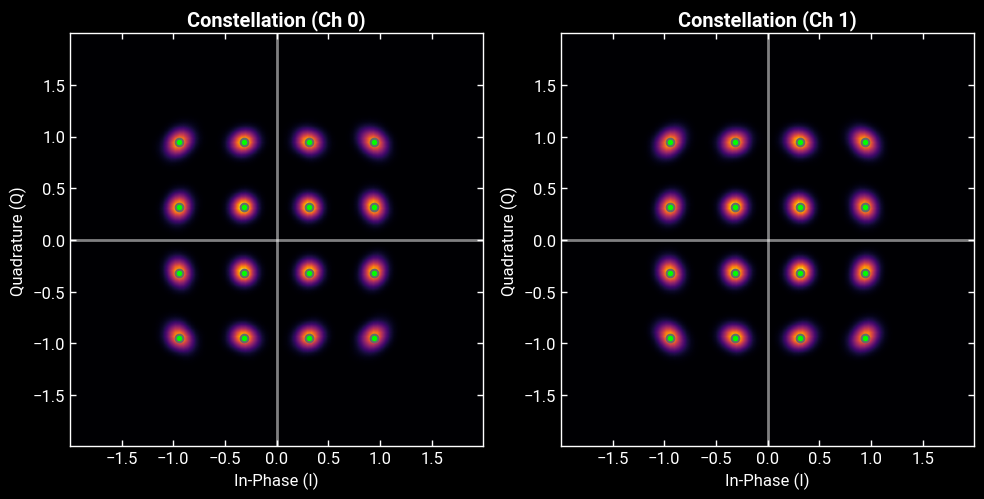

In [43]:
eq = preeqsig.copy()
eq.samples = res.y_hat
eq.sampling_rate = preeqsig.symbol_rate

eq.resolve_symbols()
eq.resolve_phase_ambiguity()
eq.demap_symbols_hard()


eq.evm(mode="blind")
eq.ser(num_train_symbols=num_train_symbols)
eq.snr(num_train_symbols=num_train_symbols)

eq.ser(num_train_symbols=num_train_symbols * 2)
eq.snr(num_train_symbols=num_train_symbols * 2)

eq.plot_constellation(show=True, overlay_ideal=True)


2026-04-06 12:27:53 [INFO] [commstools/sync.py] CPR (BPS, B=1024, joint): phase mean=90.12°, std=2.60° [6144 blocks x 8 symbols, C=2, cycle_slip_correction=True]


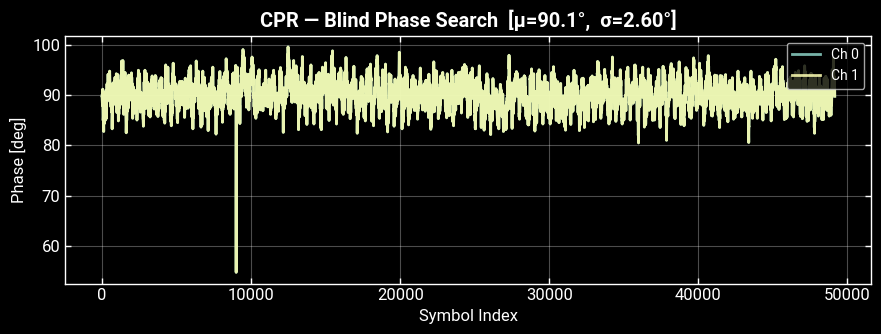

2026-04-06 12:27:53 [WARNING] [commstools/sync.py] loop_filter='butterworth': mu and beta are ignored. Use loop_bandwidth_normalized to control loop bandwidth.
2026-04-06 12:27:53 [INFO] [commstools/sync.py] CPR (DD-PLL, Butterworth, BW=0.2): phase mean=51.96°, std=262.76° [C=2]


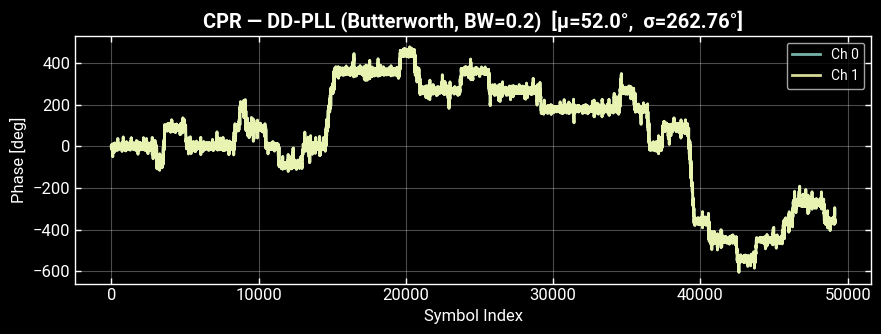

2026-04-06 12:27:53 [INFO] [commstools/core.py] Signal already at 1 sps, no downsampling needed.
2026-04-06 12:27:53 [INFO] [commstools/metrics.py] SER: 1.00e+00 (49152/49152 errors)
2026-04-06 12:27:53 [INFO] [commstools/metrics.py] SER: 8.17e-01 (40163/49152 errors)
2026-04-06 12:27:53 [INFO] [commstools/metrics.py] SER: 1.83e-01 (8997/49152 errors)
2026-04-06 12:27:53 [INFO] [commstools/metrics.py] SER: 1.00e+00 (49152/49152 errors)
2026-04-06 12:27:53 [INFO] [commstools/sync.py] Phase ambiguity resolution: ch=0, best_k=2, rotation=180.0°, SER=0.1830
2026-04-06 12:27:53 [INFO] [commstools/metrics.py] SER: 1.00e+00 (49152/49152 errors)
2026-04-06 12:27:53 [INFO] [commstools/metrics.py] SER: 8.17e-01 (40163/49152 errors)
2026-04-06 12:27:53 [INFO] [commstools/metrics.py] SER: 1.83e-01 (8997/49152 errors)
2026-04-06 12:27:53 [INFO] [commstools/metrics.py] SER: 1.00e+00 (49152/49152 errors)
2026-04-06 12:27:53 [INFO] [commstools/sync.py] Phase ambiguity resolution: ch=1, best_k=2, rotat

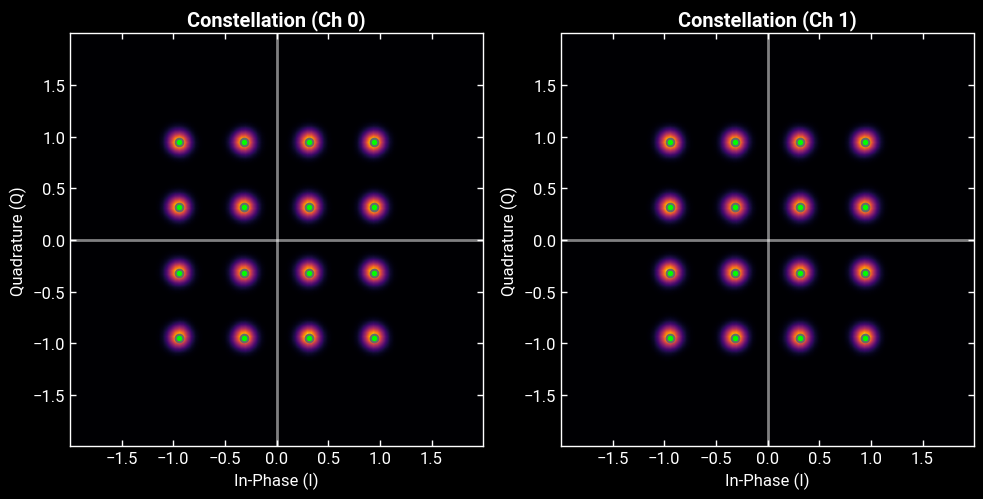

2026-04-06 12:27:54 [INFO] [commstools/metrics.py] EVM [blind] Ch0: 7.97% (-21.97 dB)
2026-04-06 12:27:54 [INFO] [commstools/metrics.py] EVM [blind] Ch1: 8.10% (-21.83 dB)
2026-04-06 12:27:54 [INFO] [commstools/core.py] Discarding 8192 training symbols for SER calculation.
2026-04-06 12:27:54 [INFO] [commstools/metrics.py] SER Ch0: 1.97e-02 (805/40960 errors)
2026-04-06 12:27:54 [INFO] [commstools/metrics.py] SER Ch1: 1.97e-02 (805/40960 errors)
2026-04-06 12:27:54 [INFO] [commstools/core.py] Discarding 8192 training symbols for SNR calculation.
2026-04-06 12:27:54 [INFO] [commstools/metrics.py] SNR Ch0: 13.64 dB
2026-04-06 12:27:54 [INFO] [commstools/metrics.py] SNR Ch1: 13.45 dB
2026-04-06 12:27:54 [INFO] [commstools/core.py] Discarding 16384 training symbols for SER calculation.
2026-04-06 12:27:54 [INFO] [commstools/metrics.py] SER Ch0: 6.10e-05 (2/32768 errors)
2026-04-06 12:27:54 [INFO] [commstools/metrics.py] SER Ch1: 6.10e-05 (2/32768 errors)
2026-04-06 12:27:54 [INFO] [commsto

array([21.987331, 21.85698 ], dtype=float32)

In [41]:
# CPR
phases_bps = recover_carrier_phase_bps(
    eq.samples,
    modulation=eq.mod_scheme,
    order=eq.mod_order,
    debug_plot=True,
    block_size=8,
    num_test_phases=1024,
    cycle_slip_correction=cpr_cycle_slip_correction,
    cycle_slip_history=cpr_cycle_slip_history // 2,
    cycle_slip_threshold=xp.pi / 4,
    joint_channels=True,
)
phases_pll = recover_carrier_phase_pll(
    eq.samples,
    modulation=eq.mod_scheme,
    order=eq.mod_order,
    debug_plot=True,
    loop_filter="butterworth",
    loop_bandwidth_normalized=cpr_pll_bandwidth,
    mu=0.2,
    beta=0.00025,
    cycle_slip_correction=cpr_cycle_slip_correction,
    cycle_slip_history=cpr_cycle_slip_history,
    joint_channels=True,
)

# Recover carrier phase

eqfoecpr = eq.copy()

eqfoecpr.samples = correct_carrier_phase(eqfoecpr.samples, phases_bps)

eqfoecpr.resolve_symbols()
eqfoecpr.resolve_phase_ambiguity()
eqfoecpr.demap_symbols_hard()

eqfoecpr.plot_constellation(show=True, overlay_ideal=True)


eqfoecpr.evm(mode="blind")
eqfoecpr.ser(num_train_symbols=num_train_symbols)
eqfoecpr.snr(num_train_symbols=num_train_symbols)

eqfoecpr.ser(num_train_symbols=num_train_symbols * 2)
eqfoecpr.snr(num_train_symbols=num_train_symbols * 2)
